# Introduction

This Jupyter notebook file contains the code for implementing a Gaussian Process Latent Variable Model (GP-LVM) using Python, and comparisons of this methodology to the standard Principal Component Analysis (PCA) method which mat be used for dimension reduction.

The primary dataset used for this project is the [`Fashion-MNIST` dataset](https://github.com/zalandoresearch/fashion-mnist), which is a publicly-available dataset that is often used for machine learning benchmarking. This dataset contains clothing items from 10 distinct groups, with an equal balance of observations from each group in the training dataset. 

# Preliminary Analysis

In order to perform the analysis, we must load the data into Python and ensure that everything is in working order.

In [ ]:
# Import necessary libraries
import torch
import numpy as np
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Set seed for consistency 
torch.manual_seed(2026)
np.random.seed(2026)

## Loading the Data

The following cells download the `Fashion-MNIST` dataset using the dataset-loading modules from `PyTorch`. By default, the dataset is already split into a training and test dataset, with 60000 entries in the training set, and 10000 in the test set.

Note that these functions download the raw datasets into local storage, and then read the data in from local storage.

In [2]:
# Download data using Pytorch
fashion_train = datasets.FashionMNIST(
    root = "data",
    train = True,
    transform = ToTensor(),
    download = True
)

fashion_test = datasets.FashionMNIST(
    root = "data",
    train = False,
    transform = ToTensor(),
    download = True
)

# Dictionary of groups and corresponding labels
fashion_label_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover", 
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot"
}

As a sanity check, we create a plot with one example image from each of the 10 classes in the training dataset.

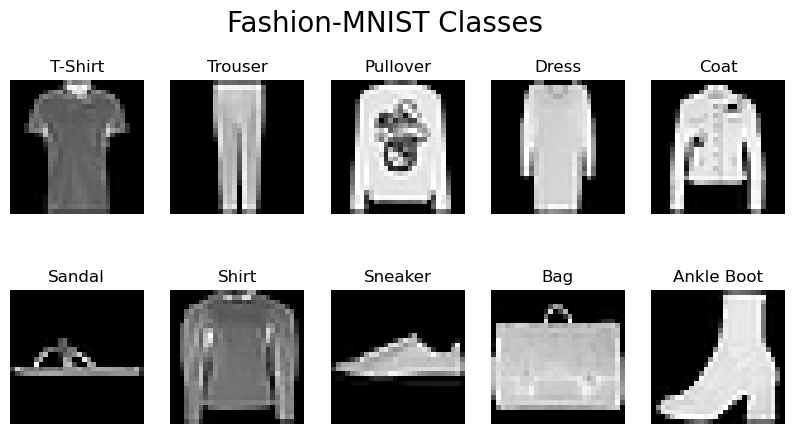

In [3]:
# Plot example images for each group 
fig = plt.figure(figsize = (10, 5))
nrow, ncol = 2, 5
for c in range(10):
    class_index = (fashion_train.targets == c).nonzero().flatten()
    rand_index = torch.randint(low = 0, high = len(class_index), size = (1,)).item()

    img, label = fashion_train[class_index[rand_index]]
    fig.add_subplot(nrow, ncol, c+1)
    plt.title(fashion_label_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap = "gray")
fig.suptitle("Fashion-MNIST Classes", size = 20)
plt.savefig("outputs/fashion-mnist-examples.pdf", dpi = 150, bbox_inches = "tight")
plt.show()

# Principal Component Analysis

In order to choose the dimension $Q$ of the lower-feature representation for the original observations, we will perform PCA on the original observation matrix $\mathbf{Y}_{\textrm{train}} \in \mathbb{R}^{60000 \times 784}$ to get a better understanding of how many dimensions are needed to well-approximate these observations.

In order to determine the variance explained by the top $n$ principal components of the data matrix $\mathbf{Y}_{\textrm{train}}$, we will compute the eigenvalues of the covariance matrix for this data matrix.

We will perform PCA to get the top principal components of $\mathbf{Y}_{\textrm{train}}$. Using these principal components, we will create a Scree plot to determine a reasonable choice of $Q$ for our dimension reduction.

In [4]:
# Rescale data
fashion_train_vecs = fashion_train.data.reshape(fashion_train.data.size(0), -1).clone()
scaler = StandardScaler()
fashion_train_scaled = scaler.fit_transform(fashion_train_vecs)

# Compute covariance matrix and eigenvalues
fashion_train_cov = fashion_train_scaled.T @ fashion_train_scaled / fashion_train_scaled.shape[0]
var_exp = np.linalg.eigvalsh(fashion_train_cov)[::-1]
prop_var_exp = var_exp / np.sum(var_exp)
cum_var_exp = np.cumsum(prop_var_exp)

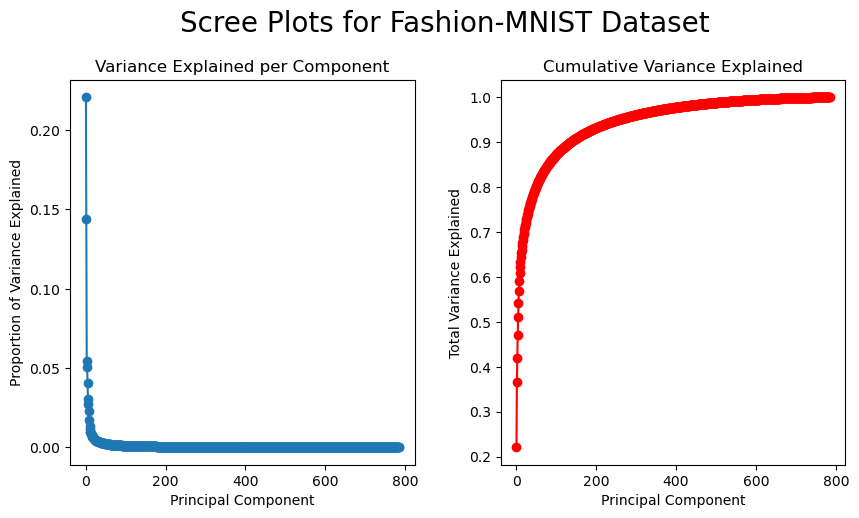

In [5]:
# Create Scree plots
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (10, 5))
ax[0].plot(range(1, len(var_exp) + 1), prop_var_exp, marker = 'o')
ax[0].set_title("Variance Explained per Component")
ax[0].set_xlabel("Principal Component")
ax[0].set_ylabel("Proportion of Variance Explained")

ax[1].plot(range(1, len(cum_var_exp) + 1), cum_var_exp, marker = 'o', color = 'red')
ax[1].set_title("Cumulative Variance Explained")
ax[1].set_xlabel("Principal Component")
ax[1].set_ylabel("Total Variance Explained")
fig.suptitle("Scree Plots for Fashion-MNIST Dataset", size = 20, y = 1.02)
plt.subplots_adjust(wspace = 0.25)
plt.savefig("outputs/fashion-mnist-scree.pdf", dpi = 150, bbox_inches = "tight")
plt.show()

Based on the Scree plots above, it is hard to find a definitive cutoff in either plot where we have a sufficiently large number of components. To find a suitable value of $Q$, we will look into thresholds for the cumulative variance explained in this dataset.

In [6]:
# Look at cumulative variance thresholds
Q_cum_80 = np.argmax(cum_var_exp >= 0.8)
Q_cum_90 = np.argmax(cum_var_exp >= 0.9)
print(f"The first {Q_cum_80} components explain 80% of the variance in the data.")
print(f"The first {Q_cum_90} components explain 90% of the variance in the data.")

The first 49 components explain 80% of the variance in the data.
The first 136 components explain 90% of the variance in the data.


In order to explain a large proportion of the variability in the `Fashion-MNIST` dataset, we need to have an inordinately large value of $Q$. This is particularly problematic for later methods such as the GP-LVM, which are quite computationally expensive. 

For ease of interpretability, we will first look into the top $Q$ principal components of the `Fashion-MNIST` dataset using $Q \in \{2, 3\}$. This will aid in the creation of plots which display certain characteristics of the data. However, as we see from the Scree plots above, these choices of $Q$ will likely fail to encapsulate a large amount of the variability in the `Fashion-MNIST` dataset.

### Sub-Sampling

In order to save on computational expenses and to prevent potential memory allocation issues, we will restrict the training dataset by taking a sub-sample of 10000 observations from this larger set. In doing this, we will ensure that the sub-sampled dataset is evenly stratified across the 10 groups of items, which matches the distributions in both the full training and test sets for the `Fashion-MNIST` dataset.

After creating this smaller sample of the dataset, we effectively have a 50/50 train-test split, as the training and test datasets will be equally-sized.

In [ ]:
subset_ids = []
for c in range(10):
    class_index = (fashion_train.targets == c).nonzero().flatten()
    sample_ids = np.random.choice(class_index, size = 1000, replace = False)
    subset_ids.append(sample_ids)

subset_ids = np.concatenate(subset_ids)
fashion_subset = torch.tensor(fashion_train_scaled[subset_ids], dtype = torch.float64)
fashion_subset_labels = fashion_train.targets.numpy()[subset_ids]

### Principal Component Plots

In order to assess how well a small subset of variables can describe the differences between clothing items in the `Fashion-MNIST` dataset, we will create plots of the first two and first three principal components of the `fashion_subset` dataset which was constructed in the previous code chunk. 

In [8]:
# Fit PCA with 2 and 3 components
PCA_2d = PCA(n_components = 2)
fashion_2d = PCA_2d.fit_transform(fashion_subset)

PCA_3d = PCA(n_components = 3)
fashion_3d = PCA_3d.fit_transform(fashion_subset)

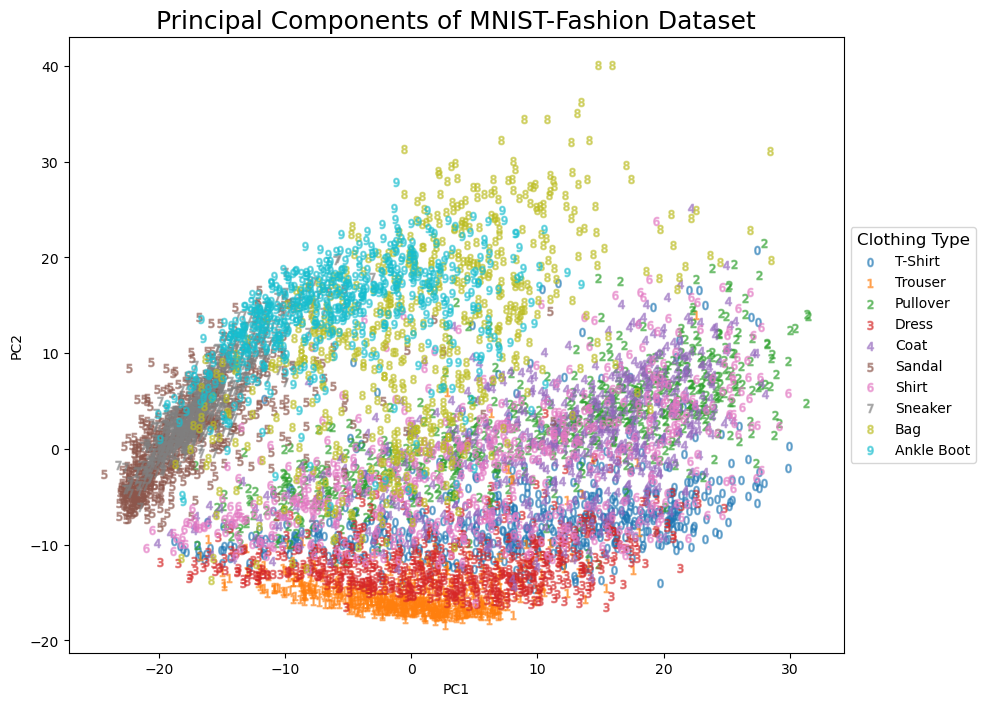

In [9]:
colors = plt.cm.tab10(np.arange(10))

# Create PCA plot for 2 dimensions
plt.figure(figsize = (10, 8))

for c in range(10):
    class_index = (fashion_subset_labels == c)
    plt.scatter(
        fashion_2d[class_index, 0], 
        fashion_2d[class_index, 1],
        marker = f"${c}$",
        color = colors[c],
        label = fashion_label_map[c],
        alpha = 0.5
    )

plt.title("Principal Components of MNIST-Fashion Dataset", size = 18)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(
    title = "Clothing Type", 
    title_fontsize = "large",
    bbox_to_anchor = (1.0, 0.5), 
    loc = "center left")
plt.savefig("outputs/fashion-pca-2d.pdf", dpi = 150, bbox_inches = "tight")
plt.show()

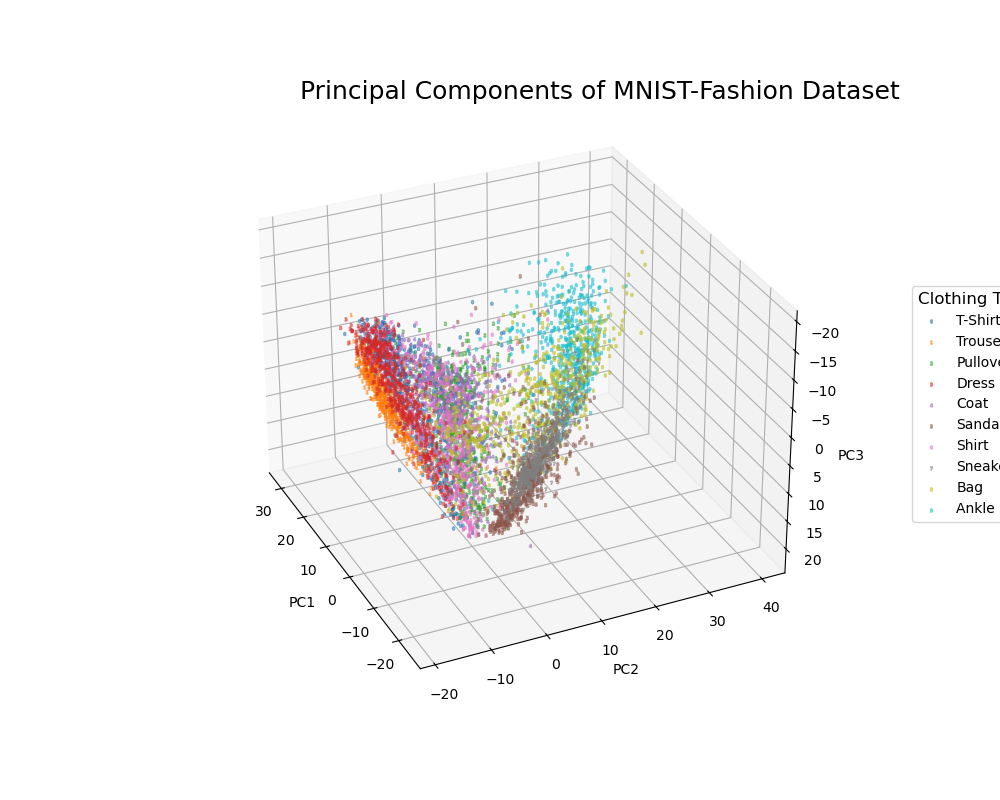

In [10]:
# Create interactive PCA plot for 3 dimensions
%matplotlib widget
fig = plt.figure(figsize = (10, 8))
ax = fig.add_subplot(111, projection = "3d")

for c in range(10):
    class_index = (fashion_subset_labels == c)
    ax.scatter(
        fashion_3d[class_index, 0], 
        fashion_3d[class_index, 1],
        fashion_3d[class_index, 2],
        marker = f"${c}$",
        label = fashion_label_map[c],
        alpha = 0.5,
        s = 5
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.legend(
    title = "Clothing Type", 
    title_fontsize = "large", 
    bbox_to_anchor = (1.25, 0.5),
    loc = "center")
ax.view_init(elev = -150, azim = 25)
fig.suptitle(
    "Principal Components of MNIST-Fashion Dataset",
    size = 18,
    x = 0.6, 
    y = 0.9)
plt.savefig("outputs/fashion-pca-3d.pdf", dpi = 150, bbox_inches = "tight")
plt.show()

# GP-LVM Modeling

The goal of this project is to reduce the dimensionality of the `Fashion-MNIST` dataset using dimension reduction methods such as a **Gaussian Process Latent Variable Model** (GP-LVM). 

For the GP-LVM, we aim to find  lower-dimensional structure which is capable of suitably representing the higher-dimensional features. In particular, we want to represent the observed feature matrix $\mathbf{Y} \in \mathbb{R}^{N \times D}$ as a reduced-feature matrix $\mathbf{X} \in \mathbb{R}^{N \times Q}$. To achieve dimension reduction, we take $Q < D$, and hopefully, we can take $Q \ll D$. 

For the `Fashion-MNIST` dataset, each clothing item is represented as a 784-dimensional vector $\mathbf{y}_{i} \in \mathbb{R}^{784}$. For the GP-LVM method, we want to represent these clothing items as some lower-dimensional observation $\mathbf{x}_{i} \in \mathbb{R}^{Q}$, where the value of $Q$ is selected prior to fitting the model. To choose $Q$, we will use **Principal Component Analysis** (PCA) to determine a suitable number of dimensions.

## Fitting the Gaussian Process

Now that we have chosen the dimensionality parameter $Q$, we can begin to fit the actual Gaussian Process model for the dimension reduction.

A Gaussian Process is fully specified by its mean and covariance functions. In Gaussian Process regression, the mean function is learned from the data, while the covariance function is typically taken to be from some parametric family which is specified via a kernel function.

For our GP-LVM model, we use the **Radial Basis Function** (RBF) kernel function with length-scale and output-scale hyperparameters. For better performance, we fit the model using **Automatic Relevance Detection** (ARD), which incorporates a separate length-scale hyperparameter $\ell_{q}$ for each dimension $q \in \{1, 2, \dots, Q\}$ of the input vectors. The model fitting process using an ARD kernel is more expensive than an RBF kernel with one common length-scale hyperparameter across all dimensions, but the resulting models tend to exhibit better performance. Furthermore, this only requires learning an additional $\mathcal{O}(Q)$ hyperparameters, while the truly expensive operation is of order $\mathcal{O}(N^{3})$, so this added cost is rather negligible.

The RBF kernel function using ARD is of the following form: $$k(x, x') = \kappa^{2}\exp\left(-\frac{1}{2}\sum_{q=1}^{Q}\frac{(x_{q} - x'_{q})^{2}}{\ell_{q}^{2}}\right)$$
Alternatively, we can write this kernel function in the form $$k(x, x') = \kappa^{2}\exp\left(-\frac{1}{2}(x - x')^{\scriptstyle{\mathsf{T}}}\Sigma^{-1}(x-x')\right),\; \textrm{where}\;\Sigma = \operatorname{diag}(\ell_{1}^{2} \cdots \ell_{Q}^{2}).$$

### GP-LVM Helper Functions

Here, we define two helper functions which we will use in fitting the GP-LVM model:
- The first function is a helper function to compute the RBF kernel using automatic relevance detection, which takes in parameters `X`, `log_len_scale` and `log_out_scale`. These respectively represent the dataset $\mathbf{X} \in \mathbb{R}^{N \times Q}$, $\{\log(\ell_{q})\}_{q=1}^{Q}$, and $\log(\kappa^{2})$. The latter two parametrizations are chosen so that the range of each variable is the entire real line, as opposed to being restricted to the positive real numbers.
- The second function computes the negative marginal log-likelihood as a function of the matrices $\mathbf{Y} \in \mathbb{R}^{N \times D}, \mathbf{X} \in \mathbb{R}^{N \times Q}$, and three sets of hyperparameters; `log_len_scales`, `log_variance`, and `log_noise`. The first two are the same as above, while `log_noise` is a term which represents the variance in the Gaussian aspect of the assumed functional relationship between $\mathbf{X}$ and $\mathbf{Y}$. 

In [18]:
def rbf_ard_kernel(X, log_len_scale, log_out_scale):
    """
    A function to compute the RBF kernel between X using automatic relevance detection    
    """
    len_scale = torch.exp(log_len_scale)
    out_scale = torch.exp(log_out_scale)

    diffs = X.unsqueeze(0) - X.unsqueeze(1)
    scaled_diffs = diffs / len_scale
    squared_dists = (scaled_diffs ** 2).sum(dim = -1)
    kernel_mat = out_scale * torch.exp(-0.5 * squared_dists)
    return kernel_mat

In [15]:
def marginal_nll(Y, X, log_len_scale, log_out_scale, log_noise):
    """
    A function to compute the marginal negative log-likelihood for the GP-LVM.
    """
    N, D = Y.shape
    noise = torch.exp(log_noise)
    KXX = rbf_ard_kernel(X, log_len_scale, log_out_scale) + noise * torch.eye(N)

    # Numerical stability
    KXX = KXX + 1e-6 * torch.eye(N)

    K_chol = torch.linalg.cholesky(KXX)
    log_det = 2.0 * torch.log(K_chol.diagonal()).sum()
    K_inv_Y = torch.cholesky_solve(Y, K_chol)
    trace_term = torch.sum(Y * K_inv_Y)

    NLL = D * log_det + trace_term
    return NLL

### Fitting the Model

Using the `rbf_ard_kernel` and `marginal_nll` functions defined above, we can fit the GP-LVM model to the `Fashion-MNIST` dataset. Here, we will set $Q = 10$, and we will use the Adam (Adaptive Moment Estimation) optimizer to maximize the log-likelihood of the Gaussian Process model. The choice of $Q$ is a bit large compared to the previously-generated plots, but the ARD aspect of the kernel used in fitting this model will help to ensure that we do not have too many parameters in the resulting fitted model.

For our initialization, we initialize the optimization loop with $\log(\ell_{q}) = 0$ for each $q \in \{1, 2, \dots, Q\}$, $\log(\kappa^{2}) = 0$, and $\log(\sigma^{2}) = 0$. Additionally, we initialize the matrix $\mathbf{X} \in \mathbb{R}^{N \times Q}$ using the first $Q$ principal components of $\mathbf{Y}$. 

---

**WARNING:** The code block below takes a very long time to run!

In [ ]:
# Set constants and initial parameters
Q = 10
log_ls = torch.nn.Parameter(torch.zeros(Q))
log_os = torch.nn.Parameter(torch.tensor(0.0))
log_noise = torch.nn.Parameter(torch.tensor(0.0))

PCA_Q = PCA(n_components = Q)
X = PCA_Q.fit_transform(fashion_subset)
X = torch.nn.Parameter(torch.tensor(X, dtype = torch.float64))

# Optimization loop
n_epochs = 500
optimizer = torch.optim.Adam([X, log_ls, log_os, log_noise], lr = 0.02)
losses = []

for epoch in range(n_epochs):
    optimizer.zero_grad()
    loss = marginal_nll(fashion_subset, X, log_ls, log_os, log_noise)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())  

In [62]:
# Save information locally to disk (prevents needing to re-run code as often)
X_fin = X.detach().numpy()
X_df = pd.DataFrame(X_fin, columns = [f"Latent-{q+1}" for q in range(Q)])
X_df["TrueClass"] = fashion_subset_labels
X_df.to_csv("outputs/optim/GP-LVM-Latent.csv", index = False)

loss_df = pd.DataFrame({"Epoch": range(n_epochs), "Loss": losses})
loss_df.to_csv("outputs/optim/GP-LVM-Loss.csv", index = False)

hyper_df = pd.DataFrame(
    [torch.exp(log_ls.detach()).numpy()], 
    columns = [f"lengthscale-{q+1}" for q in range(Q)]
)
hyper_df = hyper_df.assign(
    outputscale = torch.exp(log_os).item(),
    noise = torch.exp(log_noise).item()
)
hyper_df.to_csv("outputs/optim/GP-LVM-Hyperparameters.csv")